In [59]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace , HuggingFaceEndpoint
from typing import TypedDict, Annotated,Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import os

In [60]:
load_dotenv()

True

In [61]:
model = ChatHuggingFace(llm=HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct", 
    task="text-generation",
    huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN"), 
))

In [62]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(
        description="The sentiment and give either positive or negative as output"
    )


In [63]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [64]:
structured_model = model.with_structured_output(
    SentimentSchema,
    method="json_mode"
)

structured_model2 = model.with_structured_output(DiagnosisSchema, method="json_mode")

In [65]:
prompt = "What is the sentiment of the following review? 'This software is too bad'"
structured_model.invoke(prompt)

{'This software is too bad.': -1.0}

In [66]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [67]:
def find_sentiment(state: ReviewState) -> ReviewState:
    prompt = f"For the following review find out the sentiment: \n {state['review']}"
    sentiment = structured_model.invoke(prompt)

    return {"sentiment": sentiment}

def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    if state["sentiment"] == "positive":
        return "positive_response"
    else:
        return "run_diagnosis"
    
def positive_response(state: ReviewState) -> ReviewState:
    prompt = f"""Write a warm thank-you message in response to this review:\n\n "{state["review"]}\"\n 
    Also, kindly ask the user to leave feedback on our website."""

    response = model.invoke(prompt).content

    return {"response": response}

def run_diagnosis(state: ReviewState) -> ReviewState:
    prompt = f"""Diagnose this negative review: \n\n "{state['review']}"\n"
    "Return issue_type, tone, and urgency.
   """

    response = structured_model2.invoke(prompt)

    return {"diagnosis": response}

def negative_response(state: ReviewState) -> ReviewState:
   
   diagnosis = state["diagnosis"]
   
   prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
   
   response = model.invoke(prompt).content

   return {"response": response}

In [68]:
graph = StateGraph(ReviewState)

# nodes
graph.add_node("find_sentiment", find_sentiment)
graph.add_node("positive_response", positive_response)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("negative_response", negative_response)




# edges
graph.add_edge(START, "find_sentiment")
graph.add_conditional_edges('find_sentiment', check_sentiment, )
graph.add_edge("positive_response", END)
graph.add_edge("run_diagnosis", "negative_response")
graph.add_edge("negative_response", END)

# compile and visualize
workflow = graph.compile()



In [ ]:
initial_state = { 'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."}
workflow.invoke(initial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': {'sentiment': 'NEGATIVE'},
 'diagnosis': {'issue_type': 'Technical Issue',
  'tone': 'Frustrated',
  'urgency': 'High'},
 'response': "**Case Reference:** #XXXXXX\n\nDear [User's Name],\n\nI'm so sorry to hear that you're experiencing a technical issue. I can imagine how frustrating it must be to encounter problems while trying to accomplish your task. I want to assure you that I'm here to help and will do my best to resolve the issue as quickly as possible.\n\nPlease know that I take high-priority cases like yours seriously and will work with our team to get you back on track. To better assist you, could you please provide more details about the technical issue you're facing? This will help me to identify the root cause of the pro

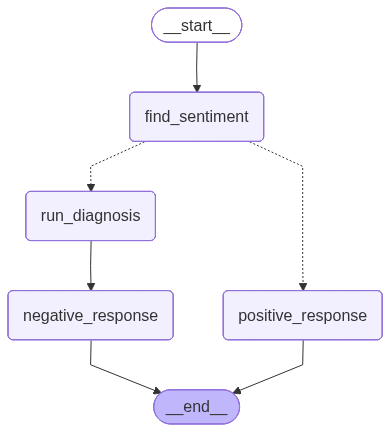

In [70]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())